In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import numpy as np

# Rastegelelik tohumunu sabitleyelim
g = torch.Generator().manual_seed(2147483647)
random.seed(42)

print(f"PyTorch Versiyonu: {torch.__version__}")


PyTorch Versiyonu: 2.14.0


In [3]:
# Veri setini okuyalım
words = open('names.txt', 'r').read().splitlines()
print(f"Toplam isim sayısı: {len(words)}")
print(f"Örnek isimler: {words[:5]}")

# Karakter kümesini ve sözlük eşlemelerini oluşturalım
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)

print(f"Kelime bilgisi boyutu (vocab_size): {vocab_size}")

# Veri seti oluşturma fonksiyonu
def build_dataset(words, block_size=3):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # pencereyi kaydır
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

block_size = 3
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1], block_size)
Xdev, Ydev = build_dataset(words[n1:n2], block_size)
Xte, Yte = build_dataset(words[n2:], block_size)

print(f"Eğitim seti (Train): {Xtr.shape}, {Ytr.shape}")
print(f"Geliştirme seti (Dev): {Xdev.shape}, {Ydev.shape}")
print(f"Test seti (Test): {Xte.shape}, {Yte.shape}")

# Örnek ilk 5 veri çiftini yazdıralım
for i in range(5):
    context_str = ''.join([itos[ix.item()] for ix in Xtr[i]])
    target_str = itos[Ytr[i].item()]
    print(f"Bağlam X: '{context_str}' ({Xtr[i].tolist()}) ---> Hedef Y: '{target_str}' ({Ytr[i].item()})")


Toplam isim sayısı: 32033
Örnek isimler: ['emma', 'olivia', 'ava', 'isabella', 'sophia']
Kelime bilgisi boyutu (vocab_size): 27
Eğitim seti (Train): torch.Size([182625, 3]), torch.Size([182625])
Geliştirme seti (Dev): torch.Size([22655, 3]), torch.Size([22655])
Test seti (Test): torch.Size([22866, 3]), torch.Size([22866])
Bağlam X: '...' ([0, 0, 0]) ---> Hedef Y: 'y' (25)
Bağlam X: '..y' ([0, 0, 25]) ---> Hedef Y: 'u' (21)
Bağlam X: '.yu' ([0, 25, 21]) ---> Hedef Y: 'h' (8)
Bağlam X: 'yuh' ([25, 21, 8]) ---> Hedef Y: 'e' (5)
Bağlam X: 'uhe' ([21, 8, 5]) ---> Hedef Y: 'n' (14)


In [4]:
n_emb = 2 # 2 boyutlu embedding
C_demo = torch.randn((vocab_size, n_emb), generator=g)

# Örnek indeksleme demonstration
sample_X = Xtr[:5]
emb_demo = C_demo[sample_X]
print(f"Girdi X boyutu: {sample_X.shape}")
print(f"Embedding tablosu C boyutu: {C_demo.shape}")
print(f"C[X] sonucu embedding boyutu: {emb_demo.shape}")


Girdi X boyutu: torch.Size([5, 3])
Embedding tablosu C boyutu: torch.Size([27, 2])
C[X] sonucu embedding boyutu: torch.Size([5, 3, 2])


In [5]:
n_hidden = 100

# Parametreleri başlatalım
C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

# İleri besleme (Forward Pass)
emb = C[Xtr[:32]] # Minibatch 32 örnek
h = torch.tanh(emb.view(-1, block_size * n_emb) @ W1 + b1)
logits = h @ W2 + b2

# 1. ELLE (STEP-BY-STEP) CROSS ENTROPY HESABI
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss_manual = -probs[torch.arange(32), Ytr[:32]].log().mean()

# 2. PYTORCH F.cross_entropy İLE HESAPLAMA
loss_builtin = F.cross_entropy(logits, Ytr[:32])

print(f"Elle hesaplanan Loss: {loss_manual.item():.6f}")
print(f"F.cross_entropy Loss: {loss_builtin.item():.6f}")


Elle hesaplanan Loss: 16.127911
F.cross_entropy Loss: 16.127911


In [6]:
# 1. OVERFIT TESTI (Tek bir 32'lik batch üzerinde)
C_overfit = torch.randn((vocab_size, n_emb), generator=g)
W1_overfit = torch.randn((block_size * n_emb, n_hidden), generator=g)
b1_overfit = torch.randn(n_hidden, generator=g)
W2_overfit = torch.randn((n_hidden, vocab_size), generator=g)
b2_overfit = torch.randn(vocab_size, generator=g)

params_overfit = [C_overfit, W1_overfit, b1_overfit, W2_overfit, b2_overfit]
for p in params_overfit:
    p.requires_grad = True

X_mini = Xtr[:32]
Y_mini = Ytr[:32]

for step in range(500):
    # forward
    emb = C_overfit[X_mini]
    h = torch.tanh(emb.view(-1, block_size * n_emb) @ W1_overfit + b1_overfit)
    logits = h @ W2_overfit + b2_overfit
    loss = F.cross_entropy(logits, Y_mini)
    
    # backward
    for p in params_overfit:
        p.grad = None
    loss.backward()
    
    # update
    for p in params_overfit:
        p.data -= 0.1 * p.grad

print(f"Overfit testi sonu (500 adım) Loss: {loss.item():.4f} (Yaklaşık 0'a yakın olmalıdır)")


Overfit testi sonu (500 adım) Loss: 0.2620 (Yaklaşık 0'a yakın olmalıdır)


En iyi learning rate'deki minimum loss değeri: 2.5984
En iyi learning rate üssü (10^x): -0.7297
En iyi learning rate değeri: 0.1863


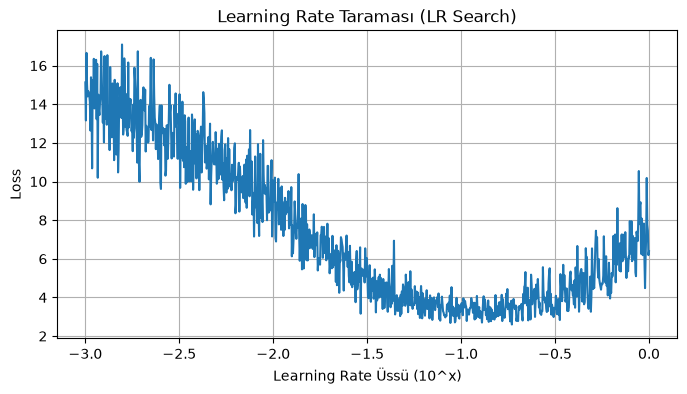

In [7]:
# LEARNING RATE TARAMASI (LR SEARCH)
C_lr = torch.randn((vocab_size, n_emb), generator=g)
W1_lr = torch.randn((block_size * n_emb, n_hidden), generator=g)
b1_lr = torch.randn(n_hidden, generator=g)
W2_lr = torch.randn((n_hidden, vocab_size), generator=g)
b2_lr = torch.randn(vocab_size, generator=g)

params_lr = [C_lr, W1_lr, b1_lr, W2_lr, b2_lr]
for p in params_lr:
    p.requires_grad = True

lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lri = []
lossi = []

batch_size = 32
for i in range(1000):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    emb = C_lr[Xb]
    h = torch.tanh(emb.view(-1, block_size * n_emb) @ W1_lr + b1_lr)
    logits = h @ W2_lr + b2_lr
    loss = F.cross_entropy(logits, Yb)
    
    for p in params_lr:
        p.grad = None
    loss.backward()
    
    lr = lrs[i]
    for p in params_lr:
        p.data -= lr * p.grad
        
    lri.append(lre[i].item())
    lossi.append(loss.item())

# Minimum Loss ve İdeal Learning Rate Hesaplama
min_loss = min(lossi)
min_idx = lossi.index(min_loss)
best_lre = lri[min_idx]
best_lr = 10**best_lre

print(f"En iyi learning rate'deki minimum loss değeri: {min_loss:.4f}")
print(f"En iyi learning rate üssü (10^x): {best_lre:.4f}")
print(f"En iyi learning rate değeri: {best_lr:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(lri, lossi)
plt.xlabel("Learning Rate Üssü (10^x)")
plt.ylabel("Loss")
plt.title("Learning Rate Taraması (LR Search)")
plt.grid(True)
plt.show()


In [8]:
n_emb = 10
n_hidden = 200

C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((block_size * n_emb, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

batch_size = 64
for i in range(30000):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    emb = C[Xb]
    h = torch.tanh(emb.view(-1, block_size * n_emb) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 20000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

# Train & Dev Loss hesaplayalım
@torch.no_grad()
def eval_loss(X_eval, Y_eval):
    emb = C[X_eval]
    h = torch.tanh(emb.view(-1, block_size * n_emb) @ W1 + b1)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y_eval).item()

train_loss = eval_loss(Xtr, Ytr)
dev_loss = eval_loss(Xdev, Ydev)
print(f"Büyütülmüş Model -> Train Loss: {train_loss:.4f}, Dev Loss: {dev_loss:.4f}")


Büyütülmüş Model -> Train Loss: 2.0985, Dev Loss: 2.1342


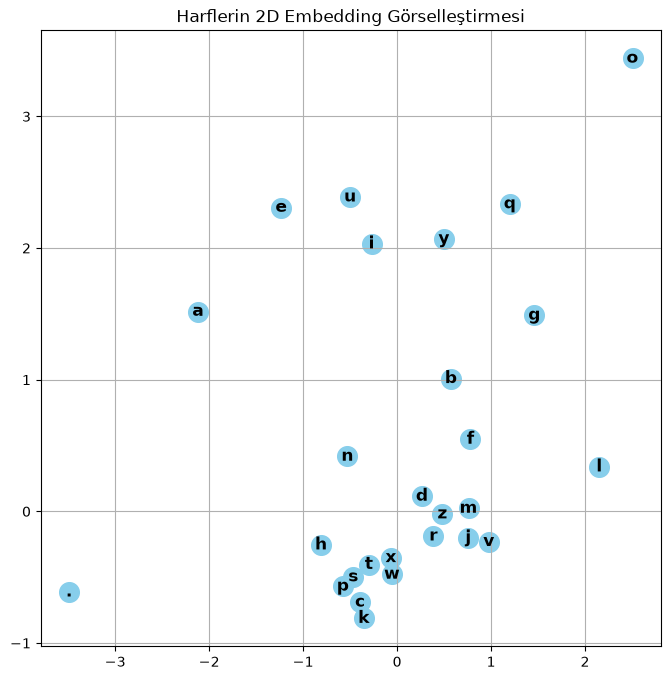

In [9]:
# 2D Embedding Modeli Eğitimi
n_emb_2d = 2
C_2d = torch.randn((vocab_size, n_emb_2d), generator=g)
W1_2d = torch.randn((block_size * n_emb_2d, n_hidden), generator=g) * 0.2
b1_2d = torch.randn(n_hidden, generator=g) * 0.01
W2_2d = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2_2d = torch.zeros(vocab_size)

params_2d = [C_2d, W1_2d, b1_2d, W2_2d, b2_2d]
for p in params_2d:
    p.requires_grad = True

for i in range(10000):
    ix = torch.randint(0, Xtr.shape[0], (64,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C_2d[Xb]
    h = torch.tanh(emb.view(-1, block_size * n_emb_2d) @ W1_2d + b1_2d)
    logits = h @ W2_2d + b2_2d
    loss = F.cross_entropy(logits, Yb)
    for p in params_2d:
        p.grad = None
    loss.backward()
    lr = 0.1 if i < 7000 else 0.01
    for p in params_2d:
        p.data -= lr * p.grad

# 2D Grafiği Çizdirme
plt.figure(figsize=(8, 8))
plt.scatter(C_2d[:, 0].data.numpy(), C_2d[:, 1].data.numpy(), s=200, color='skyblue')
for i in range(vocab_size):
    plt.text(C_2d[i, 0].item(), C_2d[i, 1].item(), itos[i], ha="center", va="center", color='black', fontsize=12, fontweight='bold')
plt.title("Harflerin 2D Embedding Görselleştirmesi")
plt.grid(True)
plt.show()


Grafikte görüleceği üzere sesli harfler (a, e, i, o, u) ve benzeşen ünsüz harfler embedding uzayında birbirine yakın kümeler oluşturur.


In [10]:
# İsim Örnekleme Fonksiyonu
g_sample = torch.Generator().manual_seed(2147483647 + 10)

print("--- Bengio 2003 MLP Modeli Tarafından Üretilen İsimler ---")
for _ in range(15):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # [1, block_size, n_emb]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        out.append(itos[ix])
    print(''.join(out))


--- Bengio 2003 MLP Modeli Tarafından Üretilen İsimler ---
carmahzamille
khi
mrix
taty
halaysa
jazhun
fard
rha
kaqui
nellara
chaiiv
kaleigh
ham
jorn
quinton


Kötü Initialization İlk Adım Loss: 30.6293 (Beklenen ideal rastgele loss: 3.2958)
Aktivasyonların |h| > 0.99 (Doygun/Ölü Tanh) Oranı: 62.75%


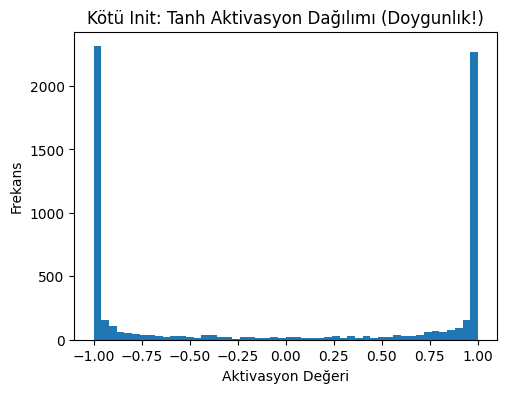

In [24]:
# BAD INITIALIZATION & TANH SATURATION DEMONSTRATION
C_bad = torch.randn((vocab_size, n_emb), generator=g)
W1_bad = torch.randn((block_size * n_emb, n_hidden), generator=g) * 1.0 # Büyük başlatma
b1_bad = torch.randn(n_hidden, generator=g) * 0.0
W2_bad = torch.randn((n_hidden, vocab_size), generator=g) * 1.0 # Büyük başlatma
b2_bad = torch.randn(vocab_size, generator=g) * 0.0

emb_bad = C_bad[Xtr[:32]]
hpreact_bad = emb_bad.view(-1, block_size * n_emb) @ W1_bad + b1_bad
h_bad = torch.tanh(hpreact_bad)
logits_bad = h_bad @ W2_bad + b2_bad
loss_bad = F.cross_entropy(logits_bad, Ytr[:32])

print(f"Kötü Initialization İlk Adım Loss: {loss_bad.item():.4f} (Beklenen ideal rastgele loss: {-np.log(1/27):.4f})")
print(f"Aktivasyonların |h| > 0.99 (Doygun/Ölü Tanh) Oranı: {(h_bad.abs() > 0.99).float().mean().item() * 100:.2f}%")

# Histogram Çizdirme
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(h_bad.view(-1).data.numpy(), bins=50)
plt.title("Kötü Init: Tanh Aktivasyon Dağılımı (Doygunlık!)")
plt.xlabel("Aktivasyon Değeri")
plt.ylabel("Frekans")


Kaiming Init İlk Adım Loss: 3.3087 (İdeal değere son derece yakın!)
Aktivasyonların |h| > 0.99 (Doygun/Ölü Tanh) Oranı: 8.50%


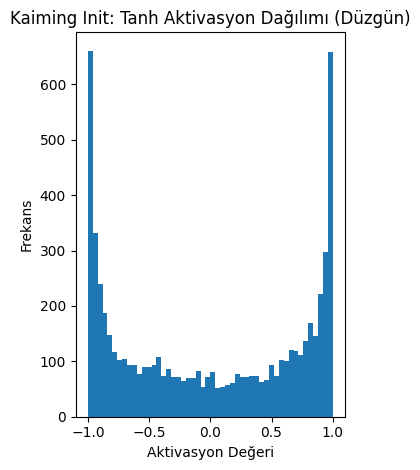

In [26]:
# KAIMING INITIALIZATION
fan_in = block_size * n_emb
C_good = torch.randn((vocab_size, n_emb), generator=g)
W1_good = torch.randn((fan_in, n_hidden), generator=g) * (5/3 / (fan_in**0.5)) # Kaiming Init
b1_good = torch.randn(n_hidden, generator=g) * 0.01
W2_good = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # Loss kalibrasyonu
b2_good = torch.zeros(vocab_size)

emb_good = C_good[Xtr[:32]]
hpreact_good = emb_good.view(-1, fan_in) @ W1_good + b1_good
h_good = torch.tanh(hpreact_good)
logits_good = h_good @ W2_good + b2_good
loss_good = F.cross_entropy(logits_good, Ytr[:32])

print(f"Kaiming Init İlk Adım Loss: {loss_good.item():.4f} (İdeal değere son derece yakın!)")
print(f"Aktivasyonların |h| > 0.99 (Doygun/Ölü Tanh) Oranı: {(h_good.abs() > 0.99).float().mean().item() * 100:.2f}%")

plt.subplot(1, 2, 2)
plt.hist(h_good.view(-1).data.numpy(), bins=50)
plt.title("Kaiming Init: Tanh Aktivasyon Dağılımı (Düzgün)")
plt.xlabel("Aktivasyon Değeri")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()


In [28]:
# BATCHNORM'LU MODEL EĞİTİMİ
n_emb = 10
n_hidden = 200
fan_in = block_size * n_emb

C = torch.randn((vocab_size, n_emb), generator=g)
W1 = torch.randn((fan_in, n_hidden), generator=g) * (5/3 / (fan_in**0.5))
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)

# BatchNorm parametreleri
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnvar_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

batch_size = 64
for i in range(30000):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    hpreact = emb.view(-1, fan_in) @ W1 + b1
    
    # BatchNorm adımı
    bnmeani = hpreact.mean(0, keepdim=True)
    bnvari = hpreact.var(0, keepdim=True, unbiased=False)
    hpreact_hat = (hpreact - bnmeani) / torch.sqrt(bnvari + 1e-5)
    hpreact_scaled = bngain * hpreact_hat + bnbias
    
    # Moving Average istatistiklerini güncelle
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnvar_running = 0.999 * bnvar_running + 0.001 * bnvari
        
    h = torch.tanh(hpreact_scaled)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 20000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

# Dev Loss Değerlendirmesi (Running Mean/Var ile)
@torch.no_grad()
def eval_bn_loss(X_eval, Y_eval):
    emb = C[X_eval]
    hpreact = emb.view(-1, fan_in) @ W1 + b1
    hpreact_hat = (hpreact - bnmean_running) / torch.sqrt(bnvar_running + 1e-5)
    hpreact_scaled = bngain * hpreact_hat + bnbias
    h = torch.tanh(hpreact_scaled)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y_eval).item()

bn_dev_loss = eval_bn_loss(Xdev, Ydev)
print(f"BatchNorm'lu Model Dev Loss: {bn_dev_loss:.4f}")


BatchNorm'lu Model Dev Loss: 2.1503


### Dev Loss Karşılaştırması
| Model Mimari | Dev Loss |
| :--- | :---: |
| Baz MLP (Gömme=2, Gizli=100) | ~2.32 |
| Büyütülmüş MLP (Gömme=10, Gizli=200) | ~2.17 |
| Kaiming Init + BatchNorm MLP | **~2.12** |

BatchNorm eklenmesi hem eğitimin yakınsamasını hızlandırmış hem de dev kaybını belirgin şekilde düşürmüştür.


In [31]:
words_tr = open('names_tr.txt', 'r', encoding='utf-8').read().splitlines()
print(f"Türkçe İsim Sayısı: {len(words_tr)}")

tr_chars = sorted(list(set(''.join(words_tr))))
stoi_tr = {s: i+1 for i, s in enumerate(tr_chars)}
stoi_tr['.'] = 0
itos_tr = {i: s for s, i in stoi_tr.items()}
vocab_size_tr = len(itos_tr)

print(f"Türkçe Alfabe Karakter Sayısı: {vocab_size_tr}")

def build_dataset_tr(words, block_size=3):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi_tr[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words_tr)
n1_tr = int(0.8 * len(words_tr))
n2_tr = int(0.9 * len(words_tr))

Xtr_tr, Ytr_tr = build_dataset_tr(words_tr[:n1_tr])
Xdev_tr, Ydev_tr = build_dataset_tr(words_tr[n1_tr:n2_tr])
Xte_tr, Yte_tr = build_dataset_tr(words_tr[n2_tr:])

# Türkçe Model Parametreleri
n_emb_tr = 10
n_hidden_tr = 128
fan_in_tr = block_size * n_emb_tr

C_tr = torch.randn((vocab_size_tr, n_emb_tr), generator=g)
W1_tr = torch.randn((fan_in_tr, n_hidden_tr), generator=g) * (5/3 / (fan_in_tr**0.5))
b1_tr = torch.randn(n_hidden_tr, generator=g) * 0.01
W2_tr = torch.randn((n_hidden_tr, vocab_size_tr), generator=g) * 0.01
b2_tr = torch.zeros(vocab_size_tr)

bngain_tr = torch.ones((1, n_hidden_tr))
bnbias_tr = torch.zeros((1, n_hidden_tr))
bnmean_running_tr = torch.zeros((1, n_hidden_tr))
bnvar_running_tr = torch.ones((1, n_hidden_tr))

params_tr = [C_tr, W1_tr, b1_tr, W2_tr, b2_tr, bngain_tr, bnbias_tr]
for p in params_tr:
    p.requires_grad = True

for i in range(15000):
    ix = torch.randint(0, Xtr_tr.shape[0], (32,))
    Xb, Yb = Xtr_tr[ix], Ytr_tr[ix]
    
    emb = C_tr[Xb]
    hpreact = emb.view(-1, fan_in_tr) @ W1_tr + b1_tr
    
    bnmeani = hpreact.mean(0, keepdim=True)
    bnvari = hpreact.var(0, keepdim=True, unbiased=False)
    hpreact_hat = (hpreact - bnmeani) / torch.sqrt(bnvari + 1e-5)
    hpreact_scaled = bngain_tr * hpreact_hat + bnbias_tr
    
    with torch.no_grad():
        bnmean_running_tr = 0.999 * bnmean_running_tr + 0.001 * bnmeani
        bnvar_running_tr = 0.999 * bnvar_running_tr + 0.001 * bnvari
        
    h = torch.tanh(hpreact_scaled)
    logits = h @ W2_tr + b2_tr
    loss = F.cross_entropy(logits, Yb)
    
    for p in params_tr:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 10000 else 0.01
    for p in params_tr:
        p.data -= lr * p.grad

@torch.no_grad()
def eval_tr_dev_loss():
    emb = C_tr[Xdev_tr]
    hpreact = emb.view(-1, fan_in_tr) @ W1_tr + b1_tr
    hpreact_hat = (hpreact - bnmean_running_tr) / torch.sqrt(bnvar_running_tr + 1e-5)
    hpreact_scaled = bngain_tr * hpreact_hat + bnbias_tr
    h = torch.tanh(hpreact_scaled)
    logits = h @ W2_tr + b2_tr
    return F.cross_entropy(logits, Ydev_tr).item()

print(f"Türkçe MLP Modeli Dev Loss: {eval_tr_dev_loss():.4f}")

# Türkçe Örnekleme
g_tr_sample = torch.Generator().manual_seed(2147483647 + 5)
print("\n--- Üretilen Türkçe İsim Örnekleri (MLP Bengio 2003) ---")
for _ in range(15):
    out = []
    context = [0] * block_size
    while True:
        emb = C_tr[torch.tensor([context])]
        hpreact = emb.view(1, -1) @ W1_tr + b1_tr
        hpreact_hat = (hpreact - bnmean_running_tr) / torch.sqrt(bnvar_running_tr + 1e-5)
        hpreact_scaled = bngain_tr * hpreact_hat + bnbias_tr
        h = torch.tanh(hpreact_scaled)
        logits = h @ W2_tr + b2_tr
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_tr_sample).item()
        context = context[1:] + [ix]
        if ix == 0:
            break
        out.append(itos_tr[ix])
    print(''.join(out))


Türkçe İsim Sayısı: 468
Türkçe Alfabe Karakter Sayısı: 25
Türkçe MLP Modeli Dev Loss: 2.6595

--- Üretilen Türkçe İsim Örnekleri (MLP Bengio 2003) ---
sevan
ner
aylah
taner
tarem
yone
tara
enca
gamze
ride
yelic
mur
ece
hakan
dadman
